# **A1.2 Regresión Lineal**

Arturo Vargas Espinosa - 611377

## Introducción

El objetivo de este estudio es estudiar esa relación usando regresión lineal, una herramienta estadística que sirve para describir la relación entre variables. Primero se plantea un modelo simple, usando una sola variable explicativa, y después se extiende el análisis agregando más variables para ver si el poder de predicción mejora.

Primeramente para este análisis se usará el archivo A1.2 Felicidad y GDP.csv, que contiene el nivel de felicidad reportado en 2022 y el GDP de 2020 para distintos países.


## Metodología


El conjunto de datos original contiene tres columnas. Las cuales son País, Felicidad y GDP. El acrónimo GDP proviene principalmente del inglés Gross Domestic Product, que en español se traduce como PIB o Producto Interno Bruto. Mide el valor total de todos los bienes y servicios finales producidos en un país durante un periodo específico, siendo el indicador principal de su tamaño y salud económica.

 Vamos a dividirlas por cualitativas o cuantitativas para poder hacer la regresión de una manera más eficiente

 Tabla 1. Descripción de variables de csv A1.2 Felicidad y GDP.csv

| Variable | Tipo | Descripción |
|---|---|---|
| País | Cualitativa | Es un país|
| Felicidad | Cuantitativa | Representa la felicidad |
| GDP | Cuantitativa | Numero que representa el GDP del páis|


### Modelo de regresión lineal simple

La regresión lineal simple busca la línea recta que mejor describe la relación entre dos variables: una variable de entrada que en este caso puede ser el GDP y una variable de salida (Felicidad).


### Busqueda de más datos

A veces no es suficiente para encontrar la relación de datos usando solo dos variables y una regresión lineal simple, por lo cual vamos a buscar otros variables para poder hacer un mejor analisis. Estas variables se obtendrán de otras fuentes confiables.

### Modelo de regresión lineal múltiple

Cuando ya tengamos otros datos, se va a construir modelo de regresión lineal múltiple, que es básicamente la misma idea que la regresión simple, pero usando varias variables de entrada al mismo tiempo en lugar de solo una. La diferencia importante es que ahora cada coeficiente se interpreta "controlando" por las demás variables: indica el efecto de esa variable sobre la felicidad, manteniendo el resto de las variables sin cambio.

Para evaluar este modelo se revisará:

- Se usara el *p-value*, para saber cuáles sí parecen tener un efecto real.

- La significancia del modelo completo, usando el **F-Value**, va a evualar si el modelo completo si tiene algun valor para sacar la felicidad
- La calidad general del modelo (R² y error residual), comparándola con la del modelo simple.


## Exploración de los Datos

Empezamos importando la libreria de pandas y numpy al igual usando 'read_csv' para leer el csv de 'A1.2 Felicidad y GDP'

Igualmente se imprime las primeras 15 tuplas usando df.head(15)

In [1]:
import pandas as pd
import numpy as np
df=pd.read_csv('/content/A1.2 Felicidad y GDP.csv')

print(df.head(15))

           Pais  Felicidad           GDP
0       Finland     7.8210  2.718370e+11
1       Denmark     7.6362  3.560850e+11
2       Iceland     7.5575  2.171808e+10
3   Switzerland     7.5116  7.522480e+11
4   Netherlands     7.4149  9.138650e+11
5    Luxembourg     7.4040  7.335313e+10
6        Sweden     7.3843  5.414870e+11
7        Norway     7.3651  3.621980e+11
8        Israel     7.3638  4.071010e+11
9   New Zealand     7.1998  2.117350e+11
10      Austria     7.1630  4.332580e+11
11    Australia     7.1621  1.327840e+12
12      Ireland     7.0408  4.258890e+11
13      Germany     7.0341  3.846410e+12
14       Canada     7.0251  1.645420e+12


* Vamos a usar 'df.shape' para ver cual es la cantidad de observaciones que tenemos en el dataset, en lo que podemos observar que tenemos 141 observaciones a contraste de las 3 variables. Estos 141 obersvaciones son para 141 paises de la cual vamos a estar usando su información
* También se utilizo '.info' para rechecar que las variables si sean la distinción entre cualitativa y cuantitativa

In [2]:
print(df.shape)

print(df.info())

(141, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141 entries, 0 to 140
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Pais       141 non-null    object 
 1   Felicidad  141 non-null    float64
 2   GDP        141 non-null    float64
dtypes: float64(2), object(1)
memory usage: 3.4+ KB
None


Se va a poner como x el GDP y como 'y' la variable de felicidad, que es la que estamos intentando estimar usando x por ahora

In [3]:
x=df.GDP
y=df.Felicidad

Ahora vamos a importar la libreria de matplot lib para graficar los puntos para ver si se ve algun tipo de relación inicial dentro de los datos usando plt.scatter(X,Y) que toma las variables X (**GDP**) y Y (**Felicidad**)

Ponemos los labels usando xlabel/ylabel, y finalmente usamos plt.show() para enseñar la grafica

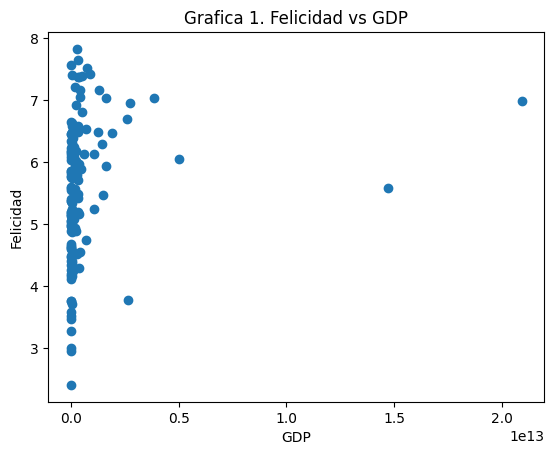

In [4]:
import matplotlib.pyplot as plt
plt.scatter(x, y)
plt.xlabel("GDP")
plt.ylabel("Felicidad")
plt.title("Grafica 1. Felicidad vs GDP")
plt.show()

Aqui podemos ver que no se ve una linea en ningun lado de la tabla, entonces podemos ver que la relación usando solo esta variables no se ve muy convincente de que tenga algun tipo de correlación entre el GDP y Felicidad

### Limitaciones
Podemos ver claramente que con GDP como nuestra unica variable, no se va a obtener una buena vista a la relación con la felicidad, ya que un pais puede tener 10 veces menos GDP que un páis como Estados Unidos y aun asi ser mil veces más felices, el dinero y el GDP no son las unicas variables para saber si una población es más o menos feliz

## Regresión Lineal Simple


Se puede ver claramente que no hay relación en el dataset anterior, entonces voy a utilizar otro dataset para poder ver la relación con variables

Voy a utilizar un dataset llamado 'world_happiness_2024.csv'. Los datos provienen del Informe Mundial de la Felicidad, respaldado por la Red de Soluciones para el Desarrollo Sostenible de las Naciones Unidas (SDSN). El informe recopila datos a través de encuestas globales e indicadores económicos, proporcionando información sobre los impulsores de la felicidad en todo el mundo.

Vamos a leerlo con 'read_csv()' para ver cuales son los datos que provienen de este dataset

In [5]:
df2=pd.read_csv('/content/world_happiness_2024.csv', sep=';')
df2.dtypes
print(df2.head())


   Ranking      Country                  Regional indicator Ladder score  \
0      140  Afghanistan                          South Asia        1,721   
1       86      Albania          Central and Eastern Europe       5,3042   
2       84      Argelia                  Sub-Saharan Africa       5,3635   
3       48    Argentina         Latin America and Caribbean       6,1881   
4       81      Armenia  Commonwealth of Independent States       5,4549   

  GDP per capita Social support  Healthy life expectancy  \
0        2,93451              0                       62   
1        6,71748        0,57133                       74   
2        6,18327        0,73652                       72   
3        7,29612        0,85449                       73   
4         6,7441        0,71415                       73   

  Freedom to make life choices Generosity Perceptions of corruption  
0                            0    0,22638                   0,15383  
1                      0,79892    0,34403 

Podemos ver que el dataset viene escrito en notación europea con , en vez de puntos, entonces debemos de cambiarlo primero salvando en un vector las columnas numericas, y usar str.replace(',','.) para replazar la coma con el punto. Luego, usamos astype(float) para que esas columnas se cambien de cualitativas a cuantitativas


In [6]:
cols_numericas = ['Ladder score', 'GDP per capita', 'Social support',
                   'Freedom to make life choices', 'Generosity',
                   'Perceptions of corruption']

for col in cols_numericas:
    df2[col] = df2[col].str.replace(',', '.').astype(float)



In [7]:
df2.dtypes

,0
Ranking,int64
Country,object
Regional indicator,object
Ladder score,float64
GDP per capita,float64
Social support,float64
Healthy life expectancy,int64
Freedom to make life choices,float64
Generosity,float64
Perceptions of corruption,float64


### Variables del conjunto de datos

Tabla 2. Tipos de datos de df2
| Variable | Tipo de dato | Qué representa |
|---|---|---|
| Ranking | Cuantitativa (discreta) | Posición del país en la clasificación mundial de felicidad. |
| Country | Cualitativa (nominal) | Nombre del país. |
| Regional indicator | Cualitativa (nominal) | Región geográfica a la que pertenece el país. |
| Ladder score | Cuantitativa (continua) | Nivel de felicidad reportado por los habitantes del país (escala aprox. 0-10). |
| GDP per capita | Cuantitativa (continua) | PIB dividido entre la población del país; mide riqueza económica promedio por persona. |
| Social support | Cuantitativa (continua) | Qué tanto sienten los habitantes que tienen a alguien con quien contar en momentos difíciles. |
| Healthy life expectancy | Cuantitativa (continua) | Años de vida esperados en buen estado de salud. |
| Freedom to make life choices | Cuantitativa (continua) | Qué tan libres se sienten los habitantes para decidir sobre su propia vida. |
| Generosity | Cuantitativa (continua) | Qué tan común es donar o ayudar económicamente a otros, comparado con lo esperado según el ingreso del país. |
| Perceptions of corruption | Cuantitativa (continua) | Qué tanto perciben los habitantes que hay corrupción en el gobierno y en los negocios. |

Tabla Markdown (Claude)

### Explicación del código

Primero se separan las dos variables de interés del `DataFrame`: `x` guarda la columna `Ladder score` (el nivel de felicidad) y `y` guarda `Freedom to make life choices`. Después se importa `matplotlib.pyplot`, la librería que se usa para graficar.

`plt.scatter(x, y)` genera una gráfica de dispersión: cada punto representa un país, ubicado según su valor en `x` (horizontal) y en `y` (vertical). Las siguientes dos líneas simplemente ponen nombres a los ejes para que la gráfica sea más fácil de leer, y `plt.show()` la despliega en pantalla.

El objetivo de esta gráfica es puramente exploratorio: ver, antes de ajustar cualquier modelo, si a simple vista parece haber alguna tendencia entre estas dos variables.|

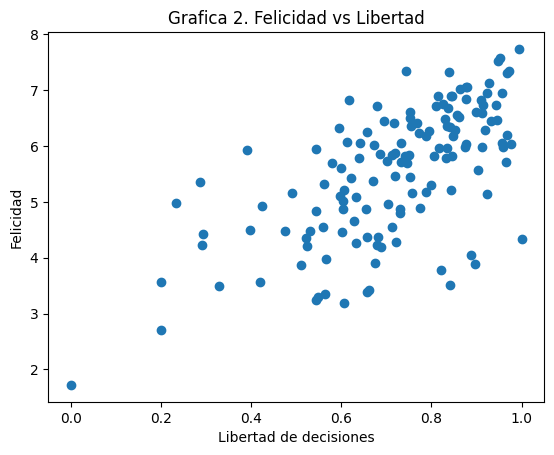

In [8]:
y=df2['Ladder score']
x=df2['Freedom to make life choices']
import matplotlib.pyplot as plt
plt.scatter(x, y)
plt.title("Grafica 2. Felicidad vs Libertad")
plt.ylabel("Felicidad")
plt.xlabel("Libertad de decisiones")
plt.show()

### Justificación de la variable

Se seleccionó **Freedom to make life choices** (libertad para tomar decisiones de vida) como variable explicativa para el modelo de regresión lineal simple. La razón detrás de esta elección es conceptual: la libertad de decidir sobre la propia vida, ya sea a nivel personal, laboral o político, está directamente relacionada con el bienestar de una persona. Cuando alguien puede elegir libremente en lugar de estar sujeto a decisiones impuestas por un gobierno, una empresa o cualquier otra autoridad externa, es de esperarse que una persona tenga mayor satisfacción y felicidad.

De acuerdo a (Helliwell F.,2026) "La libertad y la generosidad guardan una relación aún mayor con las emociones positivas que con la Escala de Cantril. Las emociones negativas se reducen significativamente gracias al apoyo social, la sensación de libertad y la ausencia de corrupción."

#### Cálculo de los coeficientes ($\beta_0$ y $\beta_1$)

- `xBar = np.mean(x)` → calcula el promedio de todos los valores de libertad. Es el punto central alrededor del cual se mide qué tanto varía cada país.
- `yBar = np.mean(y)` → lo mismo, pero para la felicidad.
- `B1num = sum((x-xBar)*(y-yBar))` → para cada país, multiplica qué tan lejos está su libertad del promedio por qué tan lejos está su felicidad del promedio, y suma todo. Este número mide si ambas variables tienden a moverse juntas (cuando una sube, la otra también).
- `B1den = sum((x-xBar)**2)` → suma qué tan dispersos están los valores de libertad respecto a su promedio, elevados al cuadrado. Sirve para "normalizar" el resultado anterior según qué tan variable es x.
- `B1 = B1num / B1den` → dividir ambos números da la pendiente de la línea: cuánto cambia la felicidad por cada unidad que cambia la libertad. En este caso dio **4.0444**.
- `B0 = yBar - (B1*xBar)` → una vez que ya sabemos la pendiente, este cálculo ubica dónde debe cruzar la línea el eje y. Dio **2.6237**.
- Las dos líneas de `print` simplemente muestran ambos valores en pantalla para poder revisarlos.

In [9]:
xBar = np.mean(x)
yBar = np.mean(y)
B1num = sum((x-xBar)*(y-yBar))
B1den = sum((x-xBar)**2)
B1 = B1num / B1den
B0 = yBar - (B1*xBar)
print("B0 =",B0)
print("B1 =",B1)

B0 = 2.6236762411237327
B1 = 4.04435765459249


Vamos a usar scatter usando Felicidad y Libertad, luego vamos a usar el yHat para ver en la grafica plt.show() los puntos con la linea que se calculo en el paso anterior
- Se puede ver que linea se ve un poco acorde a los puntos vistos en la grafica

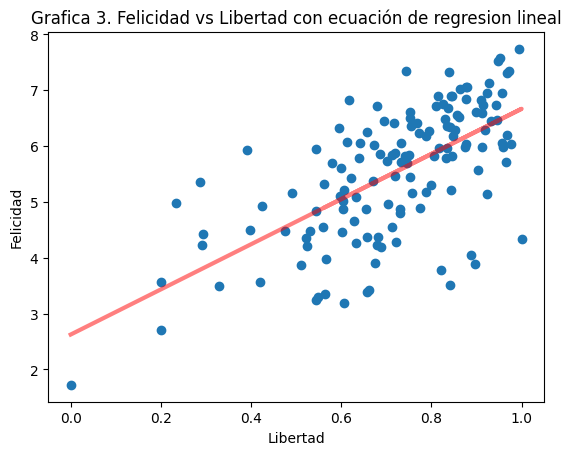

In [10]:
plt.scatter(x, y)
plt.ylabel("Felicidad")
plt.xlabel("Libertad")
plt.title("Grafica 3. Felicidad vs Libertad con ecuación de regresion lineal")
yHat = B0 + B1*x
plt.plot(x, yHat, c = "r", linewidth = 3, alpha = 0.5)
plt.show()

Aqui vamos a conseguir el RSS(Residual Sum of Squares) y el n, que son las observaciones para poder seguir sacando otros calculos

- RSS se saca usando la suma de (y-la funcion) al cuadrado
- n es el numero de observaciones (numero de paises)
- SEB1 nos dice qué tan seguro podemos estar del valor de B1 — es su margen de error.

In [11]:
RSS = sum((y - yHat)**2)
n = len(x)
SEB1 = np.sqrt(RSS / ((n-2)*sum((x-xBar)**2)))


- **RSE**: convierte el RSS en algo legible — en promedio, cuántos puntos de felicidad se equivoca el modelo. Se divide entre `n-2` (grados de libertad tras estimar B0 y B1) y se saca raíz para regresar a las unidades originales. Dio **0.906**.

- **TSS**: mide cuánto varía la felicidad entre países si no usaras ningún modelo, solo el promedio general. Es tu punto de comparación.

- **R²**: compara el error de tu modelo (RSS) contra el error sin modelo (TSS). `1 - RSS/TSS` te da qué fracción de la variación sí lograste explicar. Dio **0.415**, es decir, la libertad explica el 41.5% de por qué varía la felicidad entre países.

In [12]:

RSE=np.sqrt(RSS/(n-2))
TSS=sum((y-yBar)**2)
R2=1-RSS/TSS
print("Residual standard error =",RSE)
print("R^2 =",R2)

Residual standard error = 0.9064812947060897
R^2 = 0.4153179752694941


Se importa st de scipy.stats para poder sacar el valor de p usando st.t.sf( con el absoluto de t, y n-2)
- **t-statistic**: divide el coeficiente (B1) entre su margen de error (SEB1). Entre más grande (en valor absoluto), más fuerte es la evidencia de que la relación no es casualidad. Dio **9.90**. Lo cual podemos ver que si tiene algun tipo de relación

- **p-value**: convierte ese estadístico t en una probabilidad — qué tan probable sería ver un resultado así de fuerte si en realidad no hubiera ninguna relación entre libertad y felicidad. Se multiplica por 2 porque es una prueba de dos colas (nos importa tanto si la relación es muy positiva como muy negativa). Dio **8.6 × 10⁻¹⁸**, prácticamente cero, así que la asociación sí es estadísticamente significativa.

In [13]:
import scipy.stats as st
t = B1 / SEB1
p = st.t.sf(abs(t),n-2)*2
print("t-statistic =",t)
print("p-value =",p)

t-statistic = 9.900794265313435
p-value = 8.61433104401279e-18


# Extensión del conjunto de datos



Para acercar el análisis a un escenario más realista, el conjunto de datos original se extendió agregando tres variables adicionales, obtenidas del mismo dataset de World Happiness Report utilizado en la regresión simple (Espinoza, 2026): **Healthy life expectancy**, **Generosity** y **Perceptions of corruption**. Estas variables se eligieron porque cada una aporta una dimensión distinta del bienestar de un país que viene siendo: salud, comportamiento social y la percepción de la corrupción para complementar la libertad en la regresión simple

- **Healthy life expectancy** (esperanza de vida saludable): construida con datos de la Organización Mundial de la Salud (WHO Global Health Observatory); indica cuántos años, en promedio, se espera que una persona viva en buen estado de salud.
- **Generosity**: se calcula como el residual de una regresión entre las donaciones reportadas por los habitantes de un país (encuesta Gallup World Poll) y su GDP per cápita; mide qué tan generoso es un país más allá de lo que su nivel de ingreso haría esperar.
- **Perceptions of corruption**: promedio de respuestas binarias a dos preguntas de la encuesta Gallup World Poll sobre si la corrupción está generalizada en el gobierno y en los negocios de un país.

De acuerdo a (Helliwell F.,2026), "en el modelo global de felicidad tanto la esperanza de vida saludable como la percepción de corrupción muestran una asociación estadísticamente significativa con el nivel de felicidad promedio de un país, mientras que la generosidad no siempre resulta significativa cuando se controla por las demás variables"esto será interesante contrastar con los resultados de este análisis.

### Integración de las variables

Como las tres variables ya forman parte del mismo archivo `world_happiness_2024.csv` usado en la regresión simple, no fue necesario descargar ni unir un archivo externo adicional: bastó con usar el mismo dataset pero ahora con otras variables


# Regresión Lineal Multiple



Primeramente separamos las variables explicativas (`X`) de la variable de respuesta (`Y`). En `X` van las cuatro variables predictoras: libertad para tomar decisiones, esperanza de vida saludable, generosidad y percepción de corrupción. En `Y` va únicamente `Ladder score`, que es la variable que el modelo va a intentar predecir.

Igualmente vamos a checar si hay algun null en las columnas del modelo

In [17]:
cols_modelo = ['Ladder score', 'Freedom to make life choices', 'Healthy life expectancy',
               'Generosity', 'Perceptions of corruption']
print(df2[cols_modelo].isnull().sum())
X = df2[['Freedom to make life choices', 'Healthy life expectancy',
                   'Generosity', 'Perceptions of corruption']]
Y = df2['Ladder score']

Ladder score                    0
Freedom to make life choices    0
Healthy life expectancy         0
Generosity                      0
Perceptions of corruption       0
dtype: int64


Para ajustar el modelo se usa la librería `statsmodels`, específicamente la función `OLS` (*ordinary least squares*), la misma metodología de mínimos cuadrados que se usó "a mano" en la regresión simple, pero generalizada para trabajar con varias variables de entrada al mismo tiempo.

`sm.add_constant(X)` le agrega a `X` una columna adicional de puros unos; esto es necesario para que el modelo también calcule el intercepto ($\beta_0$), no solo los coeficientes de cada variable.

`sm.OLS(Y, sm.add_constant(X))` define el modelo, indicando cuál es la variable de respuesta y cuáles son las variables explicativas. `.fit()` es el paso que realmente ajusta el modelo: resuelve el sistema de ecuaciones (usando álgebra de matrices) para encontrar los coeficientes que minimizan el error total, guardando el resultado en `resultsMultiple`.

`resultsMultiple.summary()` imprime una tabla con todo lo necesario para interpretar el modelo: el coeficiente de cada variable, su error estándar, el estadístico t y su p-value asociado, además de la R², la R² ajustada, y el estadístico F con su p-value para el modelo completo.

Este resumen de OLS-Claude (2026)

In [16]:
import statsmodels.api as sm

modelMultiple = sm.OLS(Y, sm.add_constant(X))
resultsMultiple = modelMultiple.fit()
print(resultsMultiple.summary())

                            OLS Regression Results                            
Dep. Variable:           Ladder score   R-squared:                       0.720
Model:                            OLS   Adj. R-squared:                  0.711
Method:                 Least Squares   F-statistic:                     86.61
Date:                Sun, 16 Aug 2026   Prob (F-statistic):           2.63e-36
Time:                        17:39:17   Log-Likelihood:                -132.46
No. Observations:                 140   AIC:                             274.9
Df Residuals:                     135   BIC:                             289.6
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

# Conclusión

El modelo simple, usando únicamente Freedom to make life choices, ya mostraba una asociación fuerte y significativa con la felicidad (p < 0.001), pero solo lograba explicar el 41.5% de su variabilidad (R² = 0.415). Esto dejaba claro que, aunque la libertad importa, por sí sola no cuenta toda la historia del bienestar de un país.

Por eso, para el modelo múltiple se agregaron tres variables adicionales las cuales son: Healthy life expectancy, Generosity y Perceptions of corruption que cada una representando una dimensión distinta del bienestar (salud, comportamiento social e institucional) que no estaba cubierta por la libertad.

Los resultados confirman que esta extensión sí valió la pena: la R² subió de 0.415 a 0.720, un incremento considerable, y el estadístico F del modelo completo (86.61, p ≈ 0) confirma que, en conjunto, las variables sí están asociadas de forma significativa con la felicidad.

Sin embargo, no todas las variables aportaron por igual. Healthy life expectancy resultó ser el predictor más fuerte del modelo (t = 10.81), mientras que Generosity no mostro una asociación significativa ya que su p fue de 0.548. Perceptions of corruption quedó en una zona límite (p = 0.071), y su coeficiente positivo rcambia lo que se concluyo en el estudio de World Happiness.

También vale la pena notar que el coeficiente de libertad bajó de 4.04 (en el modelo simple) a 2.35 en el múltiple, ya que cuando se agregaron estas variables correlacionadas entre sí, se complementan y se consigue un mejor resultado

En conjunto, estos resultados respaldan la idea planteada desde la introducción: el bienestar de un país no se explica bien con una sola variable, sino que resulta de la combinación de varios factores como económicos, sociales, de salud y de gobierno para poder ver la relación entre cada uno

### Limitaciones

- Las variables adicionales provienen del mismo dataset que ya conforma el índice oficial del WHR, por lo que no son estrictamente "externas" a la construcción original de la felicidad reportada; esto podría inflar artificialmente su poder explicativo.
- El coeficiente de Perceptions of corruption resultó positivo cuando el propio WHR reportan una relación negativa, lo que sugiere un posible problema de la variable
- El dataset se limita a los 140 países con datos disponibles en el WHR, lo cual excluye países con menor capacidad estadística institucional, sesgando potencialmente los resultados hacia naciones más desarrolladas.
- El dataset solo tiene 5 variables, al tener tan pocas variables se limita que tan bueno puede ser el modelo

### Trabajo futuro

- Incorporar variables verdaderamente externas al WHR (Banco Mundial, UNDP, OCDE) para evaluar si hay más información que pueden resultar en un modelo más exacto
- Explorar datos de otros años para evaluar relaciones causales de una mejor manera
- Agregar más variables a la muestra podria ayudar con la relación para el OLS summary


# Referencias

Espinoza Y. (2026) World Happiness 2015-2024 Dataset. *kaggle*
https://www.kaggle.com/datasets/yadiraespinoza/world-happiness-2015-2024?select=world_happiness_2024.csv

Helliwell F. (2026) International evidence on happiness and social media. *World Happiness Report*
https://www.worldhappiness.report/ed/2026/international-evidence-on-happiness-and-social-media/